In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1749060018.057756   31487 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749060018.063062   31487 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749060018.076737   31487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749060018.076774   31487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749060018.076776   31487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749060018.076778   31487 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 5: Fundamentals of Machine Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit we will attempt to improve and formalize some of these intuitions about
machine learning into a solid conceptual framework.  Being good at building machine learning
models  means that you know how to accurately evaluate models, and how to balance between
training and generalization.


## 5.3 Improving model fit

To achieve the perfect fit, you must first overfit. Since you don’t know in advance
where the boundary lies, you must cross it to find it.

Thus your initial goal as you start on a problem is to achieve a model that shows some
generalization power and that is able to overfit.  Once you have such a model, you'll focus
on refining generalization by fighting overfitting.

There are 3 common problems you'll encounter when starting:

1. Training doesn’t get started: your training loss doesn’t go down over time.
2. Training gets started just fine, but your model doesn’t meaningfully generalize:
   you can’t beat the common-sense baseline you set.
3. Training and validation loss both go down over time, and you can beat your
   baseline, but you don’t seem to be able to overfit, which indicates you’re still
   underfitting.

### 5.3.1 Tuning key gradient descent parameters

Sometimes training doesn’t get started, or it stalls too early. Your loss is stuck. This is
always something you can overcome. When this happens, it’s always a problem with the configuration of the gradient
descent process: your choice of optimizer, the distribution of initial values in the
weights of your model, your learning rate, or your batch size. All these parameters are
interdependent, and as such it is usually sufficient to tune the learning rate and the
batch size while keeping the rest of the parameters constant.

Let's look at a concrete example of what we are talking about here.  Let's train MNIST model
from before with an inappropriately large learning rate value of 1.  The training loss might decrease
a bit, but it will quickly stop, and maybe even increase on the training data, which indicates
divergence.

In [4]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# notice the parameter to RMSprop, this sets the learning rate to 1
model.compile(optimizer=keras.optimizers.RMSprop(1.),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_images, train_labels,
                    epochs=50,
                    batch_size=128,
                    validation_split=0.2)

I0000 00:00:1749060022.567645   31487 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9281 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/50


I0000 00:00:1749060048.027412   31576 service.cc:152] XLA service 0x79dbf4014950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749060048.027983   31576 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1749060048.366912   31576 cuda_dnn.cc:529] Loaded cuDNN version 90300


 60/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5147 - loss: 9363.8291 

I0000 00:00:1749060051.814137   31576 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4316 - loss: 2378.8926 - val_accuracy: 0.2145 - val_loss: 2.5519
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1933 - loss: 3.9616 - val_accuracy: 0.2204 - val_loss: 2.1791
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1892 - loss: 2.4916 - val_accuracy: 0.1992 - val_loss: 2.1587
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2004 - loss: 2.3982 - val_accuracy: 0.2077 - val_loss: 2.1718
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2124 - loss: 2.2131 - val_accuracy: 0.2053 - val_loss: 2.2049
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1982 - loss: 2.4032 - val_accuracy: 0.1821 - val_loss: 2.2572
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1755 - loss: 2.4687 - val_accuracy: 0.1975 - val_loss: 2.2480
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1945 - loss: 2.4035 - val_accuracy: 0.2362 -

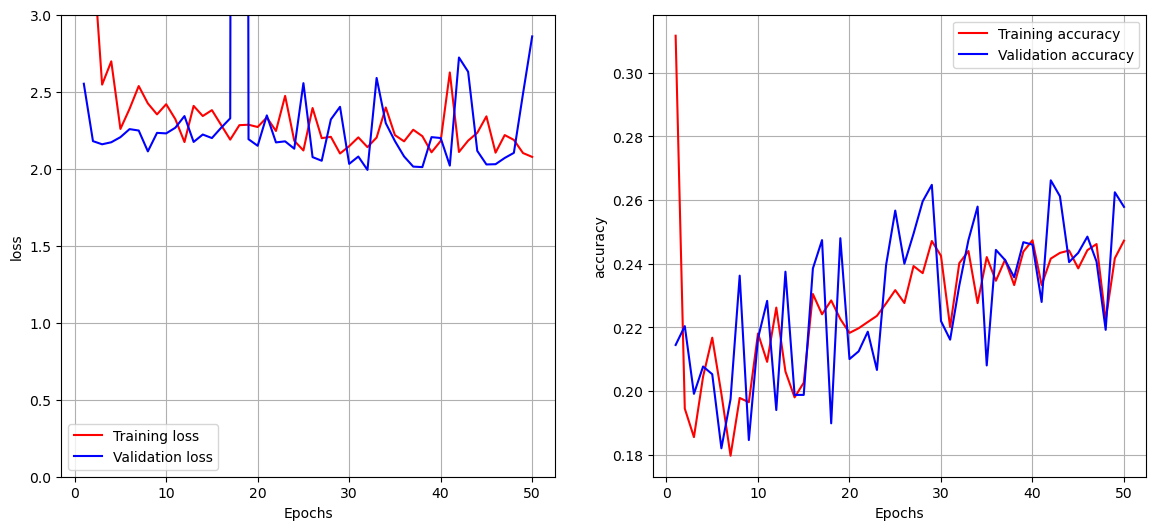

In [5]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_loss.set_ylim(0, 3) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

The model quickly reaches a training validation accuracy in the 30% range, but cannot get past that.  Let's lower the learning rate to a
more reasonable value of `1e-2`.

In [6]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# only difference from before, set learning rate to 0.01
model.compile(optimizer=keras.optimizers.RMSprop(1e-2),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_images, train_labels,
                    epochs=50,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8302 - loss: 0.8821 - val_accuracy: 0.9479 - val_loss: 0.1811
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step - accuracy: 0.9638 - loss: 0.1252 - val_accuracy: 0.9651 - val_loss: 0.1290
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9741 - loss: 0.0921 - val_accuracy: 0.9688 - val_loss: 0.1347
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9808 - loss: 0.0769 - val_accuracy: 0.9680 - val_loss: 0.1619
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9839 - loss: 0.0632 - val_accuracy: 0.9696 - val_loss: 0.1693
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9841 - loss: 0.0585 - val_accuracy: 0.9732 - val_loss: 0.1823
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9886 - loss: 0.0445 - val_accuracy: 0.9752 - val_loss: 0.1726
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9901 - loss: 0.0398 - val_accuracy: 

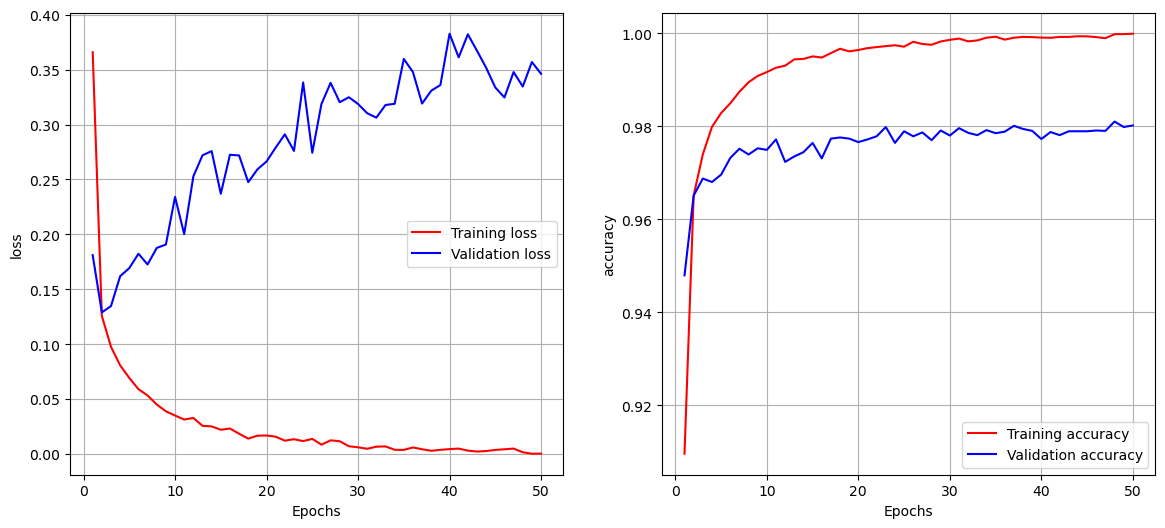

In [7]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
#ax_loss.set_ylim(0, 3) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

These learning curves look much more reasonable.  Not only is accuracy much better, but the training loss actually steadily decreases
for 30 epochs or so, indicating that it is fiting the data.

If you find yourself in a similar situation, try:

- Lowering or increasing the learning rate. A learning rate that is too high may
  lead to updates that vastly overshoot a proper fit, like in the preceding example,
  and a learning rate that is too low may make training so slow that it appears
  to stall.
- Increasing the batch size. A batch with more samples will lead to gradients that
  are more informative and less noisy (lower variance).

### 5.3.2 Leveraging better architecture priors

### 5.3.3 Increasing model capacity

If your model seems to be fitting the training data, and your validation metrics are going down and it seems to achieve at least some level
of generalization, then, you next need to get your model to start overfitting.

For example, consider using a simple logistic regression trained on MNIST dataset.

In [8]:
# remember that a logistic regression is really equivalent to a
# neural network with a single layer performing a tensor multiply
# of weight parameters and a tensor addition to the bias parameters
model = keras.Sequential([layers.Dense(10, activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(train_images, train_labels,
                                epochs=20,
                                batch_size=128,
                                validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7416 - loss: 1.0418 - val_accuracy: 0.9062 - val_loss: 0.3587
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8978 - loss: 0.3699 - val_accuracy: 0.9133 - val_loss: 0.3088
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9084 - loss: 0.3272 - val_accuracy: 0.9178 - val_loss: 0.2922
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9157 - loss: 0.3053 - val_accuracy: 0.9211 - val_loss: 0.2865
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9193 - loss: 0.2927 - val_accuracy: 0.9227 - val_loss: 0.2807
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9207 - loss: 0.2808 - val_accuracy: 0.9215 - val_loss: 0.2771
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9201 - loss: 0.2866 - val_accuracy: 0.9246 - val_loss: 0.2733
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9224 - loss: 0.2798 - val_accuracy: 0.

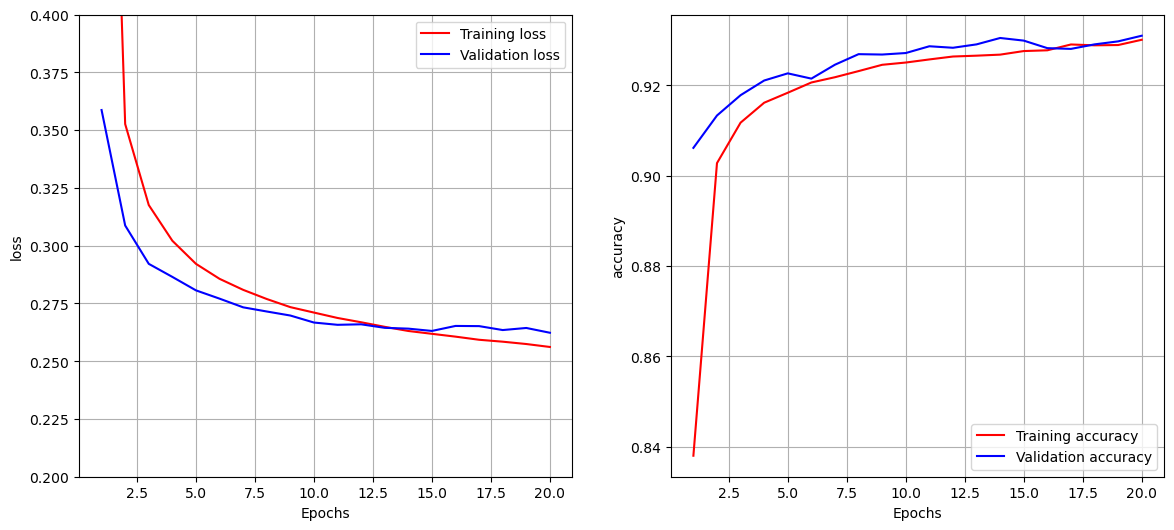

In [9]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_small_model.history, 'loss')
ax_loss.set_ylim(0.2, 0.4) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_small_model.history, 'accuracy')

What we are looking at here is the validation loss.  Validation loss seem to stall or are improving very slowly.
Instead if the model is sufficiently powerful, we would expect overfitting.  The validation loss
goes to 0.26 and just stays there.  You can fit, but you can't clearly overfit.

The sign of a model that is overfitting is that validation loss will go down to some minimum, but will begin to increase again
once overfitting begins to occur.  Remember that it should always be possible to overfit.  We saw that a neural
network can fit random data if you tell it to. If you can't seem to be able to overfit, it's likely a problem
with the **representational power** of your model. You need a bigger model with more **capacity**.

You can increate representational power by adding more layers, using bigger layers, or using kinds of
layers more appropriate to the problem.

For example, if we use a bigger model we can easily get the model to overfit.

In [10]:
model = keras.Sequential([
    layers.Dense(96, activation="relu"),
    layers.Dense(96, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_large_model = model.fit(
    train_images, train_labels,
    epochs=40,
    batch_size=128,
    validation_split=0.2)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8262 - loss: 0.6306 - val_accuracy: 0.9450 - val_loss: 0.1876
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9478 - loss: 0.1796 - val_accuracy: 0.9585 - val_loss: 0.1440
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9642 - loss: 0.1236 - val_accuracy: 0.9636 - val_loss: 0.1203
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9717 - loss: 0.0917 - val_accuracy: 0.9680 - val_loss: 0.1082
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9792 - loss: 0.0691 - val_accuracy: 0.9737 - val_loss: 0.0924
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9827 - loss: 0.0556 - val_accuracy: 0.9696 - val_loss: 0.1049
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9862 - loss: 0.0458 - val_accuracy: 0.9737 - val_loss: 0.0986
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9883 - loss: 0.0386 - val_accuracy: 0

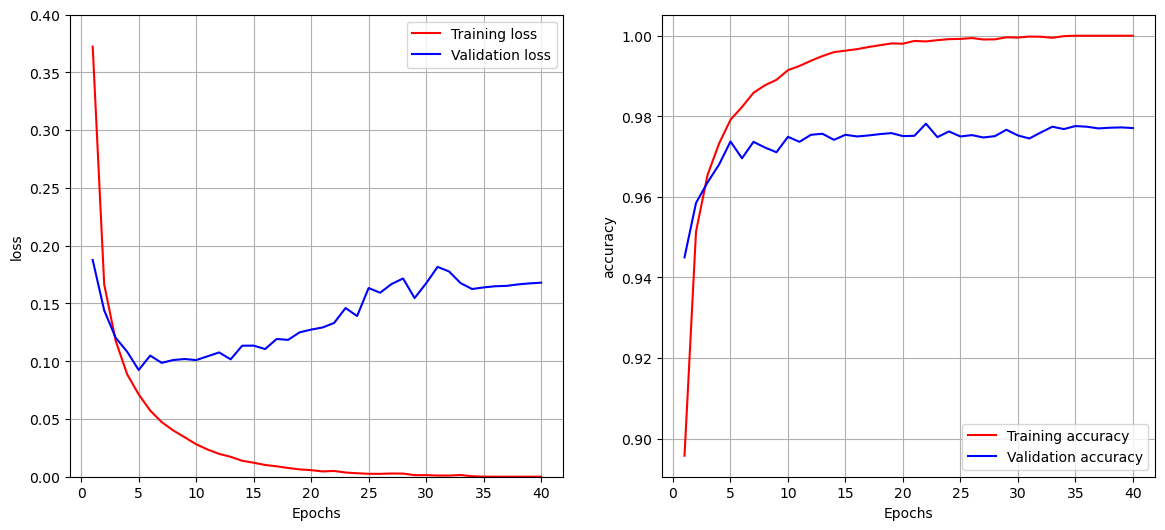

In [11]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_large_model.history, 'loss')
ax_loss.set_ylim(0.00, 0.4) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_large_model.history, 'accuracy')

The validation loss for a model with appropriate capacity looks something like the loss figure here.  
Training loss continues to improve steadily.  But validation loss decreases till epoch 5 to 10,
then clearly begins to creep back up again.  The model is overfitting here, learning the
noise in the data which decreases generalization.

## Summary 

To recap, here is what you should remember about how to evaluate machine learning models effectively.

<font color='blue'>

- 